In [235]:
import pandas as pd 
import numpy as np
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt



In [236]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [237]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [238]:
df['total_score'] = df['math score'] +df['reading score'] +df['writing score']\



df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [239]:
# to increase the accuracy we will merge the correlated cols
df['prep_lunch'] = df['test preparation course']+ '_' +df['lunch']

#df['test preparation course'] -- is telling that tution lgai h ya nhi  (parents income jyada hogi to jayega --- lunch)
#df['lunch'] -- is showing standard he ya freereduced mtlb -- rich or poor

# completed_standard
# completed_free/reduced
# none_standard
# none_free/reduced

df['parent_prep'] = df['parental level of education'] + '_' + df['test preparation course']

In [240]:
df.duplicated().sum()  # no duplicates

np.int64(0)

In [241]:
df.drop(['math score','writing score','reading score'],axis=1,inplace=True)

<Axes: xlabel='total_score', ylabel='Count'>

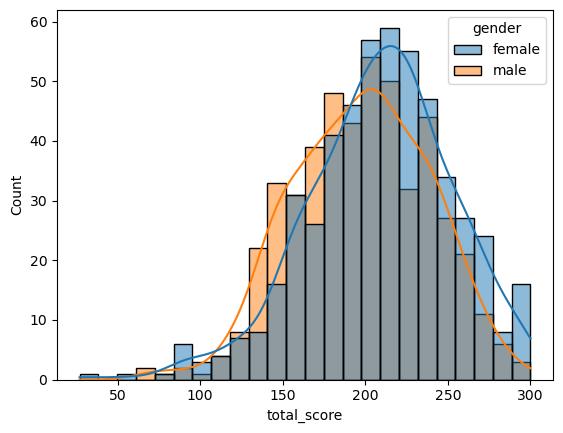

In [242]:
sns.histplot(data=df,x='total_score',kde=True,hue='gender')

In [243]:
X = df.drop('total_score',axis=1)
y = df['total_score']
# print(X['race/ethnicity'].value_counts())
# print(X['parental level of education'].value_counts())
# print(X['lunch'].value_counts())
# print(X['test preparation course'].value_counts())



In [244]:
# differentiate cat and num cols
num_feature = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns


In [245]:
#applying encoding on cat and scalling on num

from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_feature),
    ('cat',OneHotEncoder(),cat_features)
])
num_feature

Index([], dtype='object')

In [246]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [247]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor



models = {
    'lr': LinearRegression(),
    'dtree':DecisionTreeRegressor(),
    'gb':GradientBoostingRegressor(),
    'knn':KNeighborsRegressor(),
    'rfr':RandomForestRegressor(),
    'xgb':XGBRegressor(),
    'cat':CatBoostRegressor(verbose=False),
    'ada':AdaBoostRegressor(),
    'svc':SVC(),
    'lassp':Lasso(),
    'ridge':Ridge()
}
result = []
from sklearn.pipeline import Pipeline
for name,model in models.items():

    pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])

    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test,y_pred),
    mae = mean_absolute_error(y_test,y_pred),
    r2 = r2_score(y_test,y_pred),
    rmse = np.sqrt(mse)

    result.append([name,mse,mae,rmse,r2])

#result table
result_df = pd.DataFrame(result,columns=['model','mse','mae','r2','rmse'])


In [248]:
result_df

,model,mse,mae,r2,rmse
0,lr,"(1642.2624707664124,)","(31.598992429810295,)",[40.524837701913285],"(0.14877767228191185,)"
1,dtree,"(2095.8707711589623,)","(35.67291738816739,)",[45.78068120025042],"(-0.08633791990001027,)"
2,gb,"(1746.7279731185959,)","(32.230011973684384,)",[41.79387482776149],"(0.09463080498062959,)"
3,knn,"(2040.6204000000005,)","(35.227999999999994,)",[45.17322658389591],"(-0.05770038455934601,)"
4,rfr,"(2005.351861761287,)","(34.6767797780754,)",[44.78115520798104],"(-0.039419891794531425,)"
5,xgb,"(2086.058837890625,)","(35.545955657958984,)",[45.67339310682561],"(-0.0812520980834961,)"
6,cat,"(1992.7165722928858,)","(34.665208553017784,)",[44.63985408010297],"(-0.03287073128935036,)"
7,ada,"(1779.8203518987077,)","(33.084858260811785,)",[42.187917131552105],"(0.07747826560500248,)"
8,svc,"(2033.255,)","(35.615,)",[45.09162893486994],"(-0.053882728707021155,)"
9,lassp,"(1700.8001891662032,)","(32.28383509707864,)",[41.24075883353995],"(0.11843622942331589,)"
